**Проект по SQL**

Цель исследования: Выполнение заданий по SQL с помощью одного запроса, выведение результатов и их описание.

Задания

1) Посчитайте, сколько книг вышло после 1 января 2000 года;

2) Для каждой книги посчитайте количество обзоров и среднюю оценку;

3) Определите издательство, которое выпустило наибольшее число книг толще 50 страниц — так вы исключите из анализа брошюры;

4) Определите автора с самой высокой средней оценкой книг — учитывайте только книги с 50 и более оценками;

5) Посчитайте среднее количество обзоров от пользователей, которые поставили больше 48 оценок.

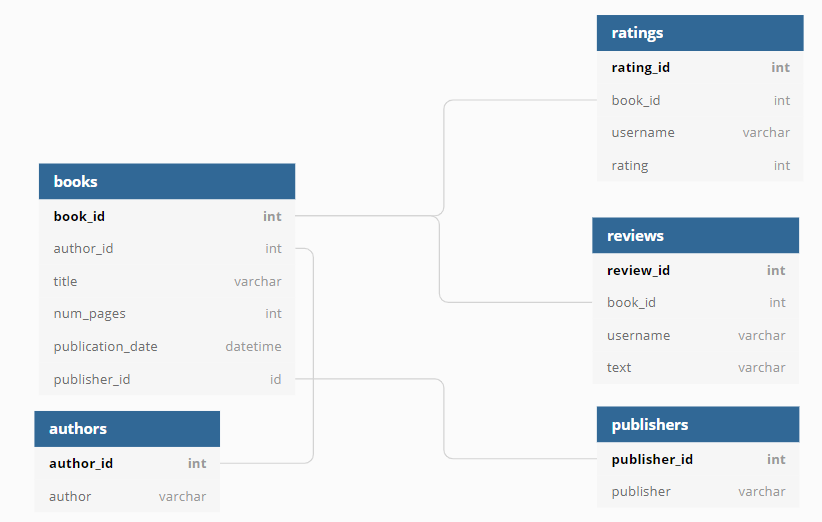

# Загрузка и изучение данных

In [1]:
# импортируем библиотеки
import pandas as pd
from sqlalchemy import text, create_engine
import seaborn as sns
import matplotlib.pyplot as plt

# устанавливаем параметры
db_config = {'user': 'praktikum_student', # имя пользователя
'pwd': 'Sdf4$2;d-d30pp', # пароль
'host': 'rc1b-wcoijxj3yxfsf3fs.mdb.yandexcloud.net',
'port': 6432, # порт подключения
'db': 'data-analyst-final-project-db'} # название базы данных
connection_string = 'postgresql://{user}:{pwd}@{host}:{port}/{db}'.format(**db_config)

# сохраняем коннектор
engine = create_engine(connection_string, connect_args={'sslmode':'require'})
con=engine.connect()

**books**

In [2]:
books = '''SELECT *
FROM books'''
pd.io.sql.read_sql(sql=text(books), con = con)

,book_id,author_id,title,num_pages,publication_date,publisher_id
0,1,546,'Salem's Lot,594,2005-11-01,93
1,2,465,1 000 Places to See Before You Die,992,2003-05-22,336
2,3,407,13 Little Blue Envelopes (Little Blue Envelope...,322,2010-12-21,135
3,4,82,1491: New Revelations of the Americas Before C...,541,2006-10-10,309
4,5,125,1776,386,2006-07-04,268
...,...,...,...,...,...,...
995,996,571,Wyrd Sisters (Discworld #6; Witches #2),265,2001-02-06,147
996,997,454,Xenocide (Ender's Saga #3),592,1996-07-15,297
997,998,201,Year of Wonders,358,2002-04-30,212
998,999,94,You Suck (A Love Story #2),328,2007-01-16,331


Таблица books  
Содержит данные о книгах:
* book_id — идентификатор книги;
* author_id — идентификатор автора;
* title — название книги;
* num_pages — количество страниц;
* publication_date — дата публикации книги;
* publisher_id — идентификатор издателя.

**authors**

In [3]:
authors = '''SELECT *
FROM authors'''
pd.io.sql.read_sql(sql=text(authors), con = con)

,author_id,author
0,1,A.S. Byatt
1,2,Aesop/Laura Harris/Laura Gibbs
2,3,Agatha Christie
3,4,Alan Brennert
4,5,Alan Moore/David Lloyd
...,...,...
631,632,William Strunk Jr./E.B. White
632,633,Zadie Smith
633,634,Zilpha Keatley Snyder
634,635,Zora Neale Hurston


Таблица authors  
Содержит данные об авторах:
* author_id — идентификатор автора;
* author — имя автора.

**publishers**

In [4]:
publishers = '''SELECT *
FROM publishers'''
pd.io.sql.read_sql(sql=text(publishers), con = con)

,publisher_id,publisher
0,1,Ace
1,2,Ace Book
2,3,Ace Books
3,4,Ace Hardcover
4,5,Addison Wesley Publishing Company
...,...,...
335,336,Workman Publishing Company
336,337,Wyatt Book
337,338,Yale University Press
338,339,Yearling


Таблица publishers  
Содержит данные об издательствах:
* publisher_id — идентификатор издательства;
* publisher — название издательства;

**ratings**

In [5]:
ratings = '''SELECT *
FROM ratings'''
pd.io.sql.read_sql(sql=text(ratings), con = con)

,rating_id,book_id,username,rating
0,1,1,ryanfranco,4
1,2,1,grantpatricia,2
2,3,1,brandtandrea,5
3,4,2,lorichen,3
4,5,2,mariokeller,2
...,...,...,...,...
6451,6452,1000,carolrodriguez,4
6452,6453,1000,wendy18,4
6453,6454,1000,jarvispaul,5
6454,6455,1000,zross,2


Таблица ratings  
Содержит данные о пользовательских оценках книг:
* rating_id — идентификатор оценки;
* book_id — идентификатор книги;
* username — имя пользователя, оставившего оценку;
* rating — оценка книги.

**reviews**

In [6]:
reviews = '''SELECT *
FROM reviews'''
pd.io.sql.read_sql(sql=text(reviews), con = con)

,review_id,book_id,username,text
0,1,1,brandtandrea,Mention society tell send professor analysis. ...
1,2,1,ryanfranco,Foot glass pretty audience hit themselves. Amo...
2,3,2,lorichen,Listen treat keep worry. Miss husband tax but ...
3,4,3,johnsonamanda,Finally month interesting blue could nature cu...
4,5,3,scotttamara,Nation purpose heavy give wait song will. List...
...,...,...,...,...
2788,2789,999,martinadam,Later hospital turn easy community. Fact same ...
2789,2790,1000,wknight,Change lose answer close pressure. Spend so now.
2790,2791,1000,carolrodriguez,Authority go who television entire hair guy po...
2791,2792,1000,wendy18,Or western offer wonder ask. More hear phone f...


Таблица reviews  
Содержит данные о пользовательских обзорах на книги:
* review_id — идентификатор обзора;
* book_id — идентификатор книги;
* username — имя пользователя, написавшего обзор;
* text — текст обзора.

### Cколько книг вышло после 1 января 2000 года

In [7]:
exercise1 = '''

SELECT COUNT(DISTINCT(book_id))
FROM books
WHERE publication_date::date > '2000-01-01'

'''
pd.io.sql.read_sql(sql=text(exercise1), con = con)

,count
0,819


После 1 января 2000 года вышло 819 книг.

### Для каждой книги посчитаем количество обзоров и среднюю оценку

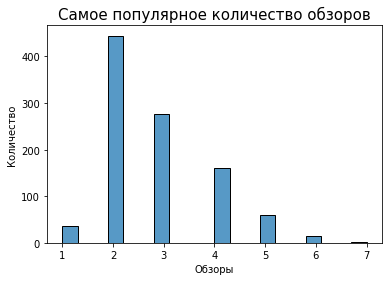

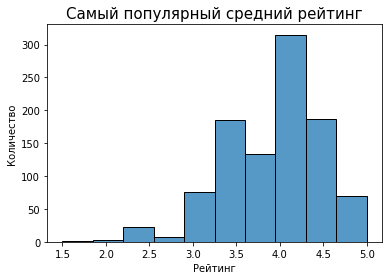

44

,book_id,title,rating,review
931,938,Triptych (Will Trent #1),5.00,2.0
960,967,Welcome to Temptation (Dempseys #1),5.00,2.0
180,182,Dead Souls,5.00,2.0
61,62,Alas Babylon,5.00,2.0
416,421,Marvel 1602,5.00,2.0
...,...,...,...,...
908,915,The World Is Flat: A Brief History of the Twen...,2.25,3.0
312,316,His Excellency: George Washington,2.00,2.0
367,371,Junky,2.00,2.0
199,202,Drowning Ruth,2.00,3.0


,book_id,title,rating,review
941,948,Twilight (Twilight #1),3.66,7.0
727,733,The Giver (The Giver #1),3.75,6.0
492,497,Outlander (Outlander #1),4.13,6.0
690,696,The Da Vinci Code (Robert Langdon #2),3.83,6.0
689,695,The Curious Incident of the Dog in the Night-Time,4.08,6.0
...,...,...,...,...
995,672,The Cat in the Hat and Other Dr. Seuss Favorites,5.00,NaN
996,83,Anne Rice's The Vampire Lestat: A Graphic Novel,3.67,NaN
997,221,Essential Tales and Poems,4.00,NaN
998,387,Leonardo's Notebooks,4.00,NaN


In [8]:
exercise2 = '''
WITH

rating AS 
(SELECT book_id, ROUND(AVG(rating),2) AS rating
FROM ratings
GROUP BY book_id),

review AS
(SELECT book_id, COUNT(DISTINCT(review_id)) AS review
FROM reviews
GROUP BY book_id)

SELECT b.book_id, b.title , rating.rating, review.review
FROM books AS b
LEFT JOIN rating ON rating.book_id=b.book_id
LEFT JOIN review ON review.book_id=b.book_id
'''
data = pd.io.sql.read_sql(sql=text(exercise2), con = con)

sns.histplot(data['review'], bins=20)
plt.title('Самое популярное количество обзоров', fontsize=15)
plt.ylabel('Количество', fontsize=10)
plt.xlabel('Обзоры', fontsize=10)
plt.show()
sns.histplot(data['rating'], bins=10)
plt.title('Самый популярный средний рейтинг', fontsize=15)
plt.ylabel('Количество', fontsize=10)
plt.xlabel('Рейтинг', fontsize=10)
plt.show()

display(data.loc[data['rating']==5, 'title'].count())
display(data.sort_values(by='rating', ascending=False))
display(data.sort_values(by='review', ascending=False))

Исследование количества обзоров и средней оценки:
- больше всего обзоров имеет книга - Twilight (Twilight #1);
- оценку 5 имеют 44 книги;
- самое популярное количество обзоров 2;
- самый популярный рейтинг 4-4,3.

### Определим издательство, которое выпустило наибольшее число книг толще 50 страниц — так вы исключите из анализа брошюры

In [9]:
exercise3 = '''

SELECT p.publisher_id, p.publisher, COUNT(DISTINCT(book_id)) AS book
FROM books AS b
LEFT JOIN publishers AS p ON p.publisher_id=b.publisher_id
WHERE num_pages > 50
GROUP BY p.publisher_id, p.publisher
ORDER BY book DESC
LIMIT 1

'''
pd.io.sql.read_sql(sql=text(exercise3), con = con)

,publisher_id,publisher,book
0,212,Penguin Books,42


Издательство, которое выпустило наибольшее число книг толще 50 страниц - Penguin Books.

### Определим автора с самой высокой средней оценкой книг — учитывайте только книги с 50 и более оценками

In [10]:
exercise4 = '''

WITH

rating AS 
(SELECT book_id, COUNT(DISTINCT(rating_id)) AS cnt
FROM ratings
GROUP BY book_id),

rating1 AS 
(SELECT book_id, ROUND(AVG(rating),2) AS rating
FROM ratings
GROUP BY book_id),

author AS (SELECT b.book_id, b.author_id, rating.cnt, rating1.rating
FROM books AS b
LEFT JOIN rating ON rating.book_id=b.book_id
LEFT JOIN rating1 ON rating1.book_id=b.book_id
WHERE cnt >= 50
ORDER BY rating DESC)

SELECT a.author_id, al.author, SUM(a.cnt), ROUND(AVG(a.rating),2) AS rating
FROM author AS a
LEFT JOIN authors AS al ON al.author_id=a.author_id
GROUP BY a.author_id, al.author
ORDER BY rating DESC
'''
pd.io.sql.read_sql(sql=text(exercise4), con = con)

,author_id,author,sum,rating
0,236,J.K. Rowling/Mary GrandPré,310.0,4.29
1,240,J.R.R. Tolkien,162.0,4.26
2,402,Markus Zusak/Cao Xuân Việt Khương,53.0,4.26
3,376,Louisa May Alcott,52.0,4.19
4,498,Rick Riordan,62.0,4.08
5,621,William Golding,71.0,3.90
6,235,J.D. Salinger,86.0,3.83
7,469,Paulo Coelho/Alan R. Clarke/Özdemir İnce,57.0,3.79
8,630,William Shakespeare/Paul Werstine/Barbara A. M...,66.0,3.79
9,106,Dan Brown,143.0,3.76


Автор с самой высокой средней оценкой книг, где 50 и более оценок - J.K. Rowling/Mary GrandPré.

### Посчитаем среднее количество обзоров от пользователей, которые поставили больше 48 оценок

In [11]:
exercise5 = '''

WITH

rating AS 
(SELECT username, COUNT(DISTINCT(rating_id)) AS cnt_rating
FROM ratings
GROUP BY username
HAVING COUNT(DISTINCT(rating_id)) > 48),

review AS 
(SELECT username, COUNT(DISTINCT(review_id)) AS cnt_review
FROM reviews
GROUP BY username),

result AS (SELECT rt.username, rw.cnt_review
FROM rating AS rt
LEFT JOIN review AS rw ON rw.username=rt.username)

SELECT AVG(cnt_review)
FROM result

'''
pd.io.sql.read_sql(sql=text(exercise5), con = con)

,avg
0,24.0


Среднее количество обзоров от пользователей, которые поставили больше 48 оценок - 24.

**Вывод:**
1) После 1 января 2000 года вышло 819 книг.

2) Исследование количества обзоров и средней оценки:
- больше всего обзоров имеет книга - Twilight (Twilight #1);
- оценку 5 имеют 44 книги;
- самое популярное количество обзоров 2;
- самый популярный рейтинг 4-4,3.

3) Издательство, которое выпустило наибольшее число книг толще 50 страниц - Penguin Books.

4) Автор с самой высокой средней оценкой книг, а также 50-ю и более оценками книг - J.K. Rowling/Mary GrandPré.

5) Среднее количество обзоров от пользователей, которые поставили больше 48 оценок - 24.